In [1]:
################################################################################
##### Pacotes
################################################################################
# Manipulação e visualização de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem estatística
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Diagnóstico de resíduos e influência
from statsmodels.stats.outliers_influence import OLSInfluence
import statsmodels.stats.api as sms
from scipy import stats


# Dataset Boston do pacote MASS (R)
boston = sm.datasets.get_rdataset("Boston", "MASS").data


In [6]:
################################################################################
##### Regressão Linear Simples
################################################################################

# Configurações gerais de plot
sns.set_theme(style="whitegrid")


################################################################################
##### Importação / Entrada dos dados
################################################################################
# Dataset Boston do pacote MASS (R)
boston = sm.datasets.get_rdataset("Boston", "MASS").data

# Inspeção rápida da estrutura (equivalente a psych::headTail() e summary())
print(boston.head())
print(boston.tail())
print(boston.info())
print(boston.describe())


      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

    black  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  
        crim   zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
501  0.06263  0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273     21.0   
502  0.04527  0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273     21.0   
503  0.06076  0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273     21.0   
504  0.10959  0.0  11.93     0  0.573  6.794 

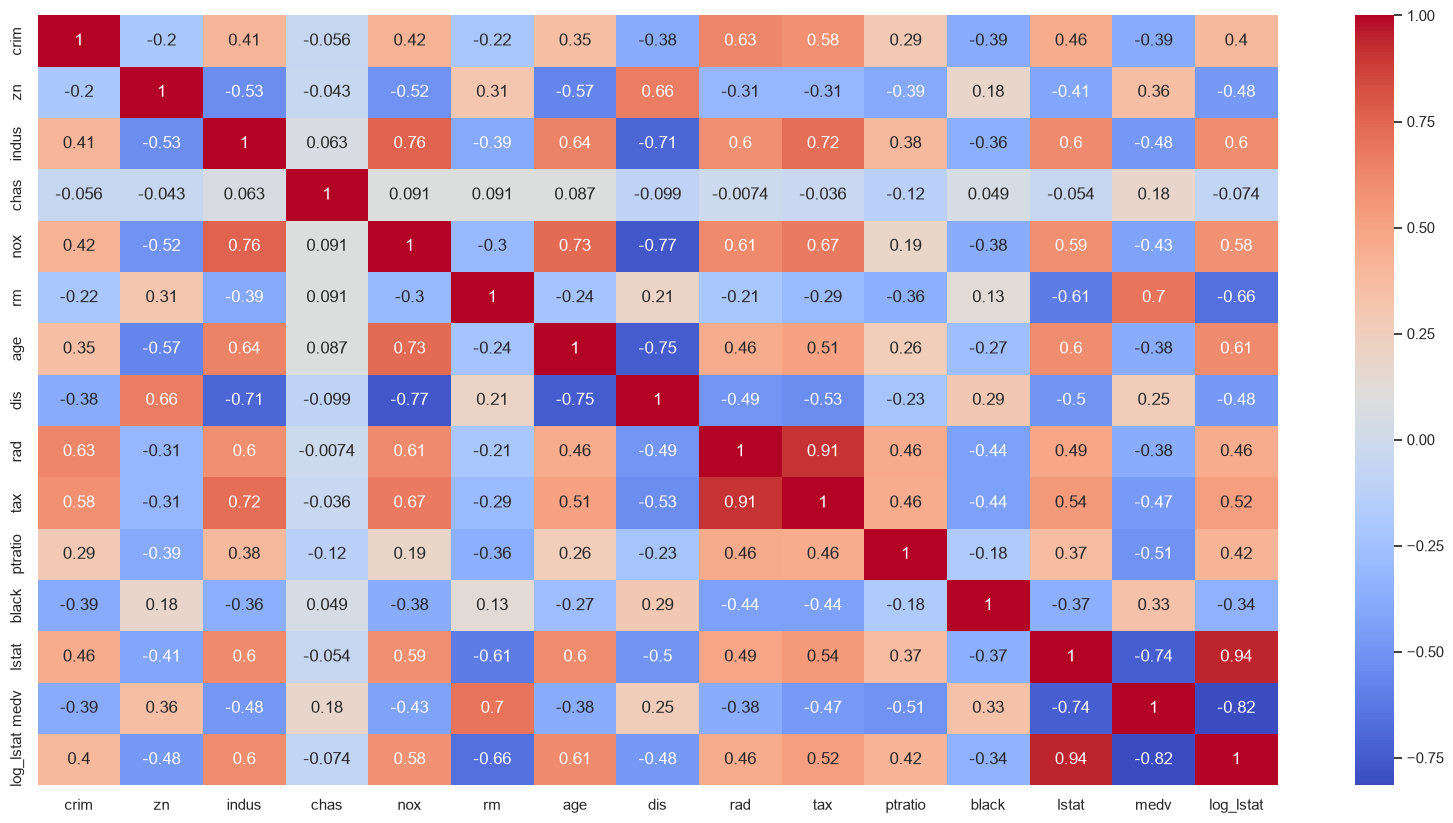

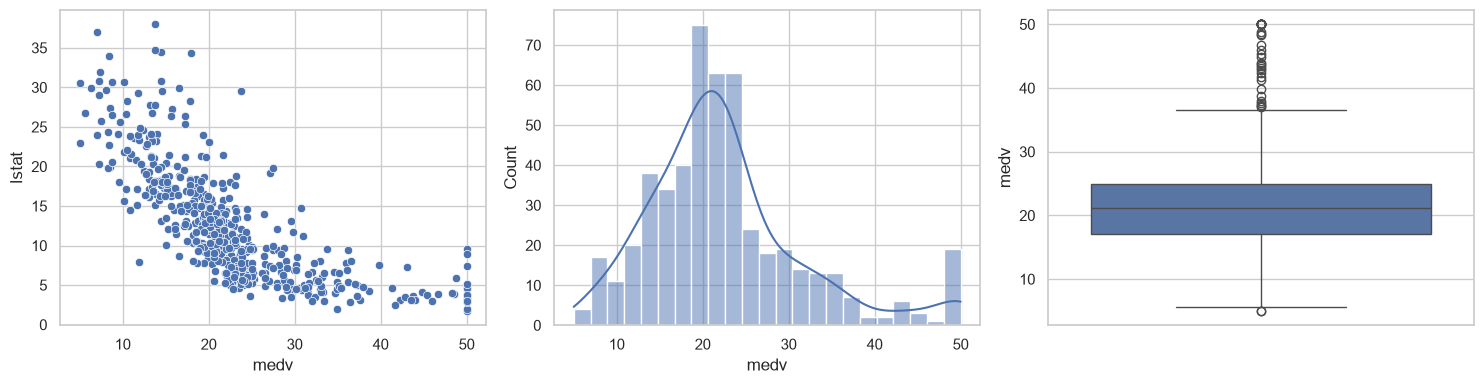

           medv     lstat
medv   1.000000 -0.737663
lstat -0.737663  1.000000


In [18]:


################################################################################
##### Preparação / Recodificação dos dados
################################################################################
# Transformações de variáveis explicativas (log, padronização/escala)
boston["log_lstat"] = np.log(boston["lstat"])
# dados["x_padronizada"] = (dados["x"] - dados["x"].mean()) / dados["x"].std()

# Definição de fatores e níveis de referência (equivalente a factor()/relevel())
# dados["grupo"] = pd.Categorical(dados["grupo"], categories=["controle", "tratamento"])
# dados["grupo"] = dados["grupo"].cat.reorder_categories(["controle", "tratamento"])


################################################################################
##### Análise descritiva / Visualização inicial
################################################################################
# AED visual e tabelas descritivas: dispersão, histogramas e boxplots
plt.figure(figsize=(20, 10))
sns.heatmap(boston.corr(), annot=True, cmap="coolwarm")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=boston, x="medv", y="lstat", ax=axes[0])
sns.histplot(data=boston, x="medv", kde=True, ax=axes[1])
sns.boxplot(data=boston, y="medv", ax=axes[2])
plt.tight_layout()
plt.show()

# Correlação simples entre x e y
print(boston[["medv", "lstat"]].corr())



In [19]:

################################################################################
##### Ajuste do Modelo
################################################################################
# Regressão linear simples: y = beta0 + beta1 * x + erro
# Usando a interface de fórmulas (semelhante ao lm() do R)

modelo = smf.ols("medv ~ log_lstat", data=boston).fit()
print(modelo.summary())



                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.664
Method:                 Least Squares   F-statistic:                     1000.
Date:                Mon, 31 Aug 2026   Prob (F-statistic):          9.28e-122
Time:                        02:13:13   Log-Likelihood:                -1563.6
No. Observations:                 506   AIC:                             3131.
Df Residuals:                     504   BIC:                             3140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     52.1248      0.965     54.004      0.0

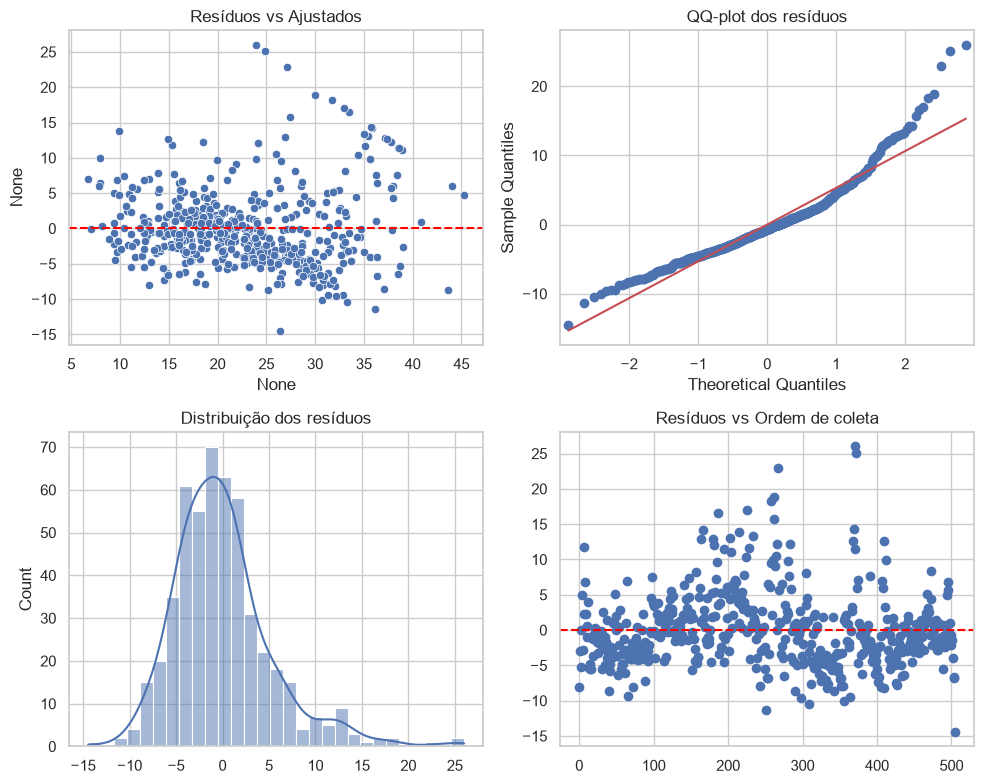

Shapiro-Wilk (normalidade): ShapiroResult(statistic=np.float64(0.9291297334627574), pvalue=np.float64(9.785019743081987e-15))
Breusch-Pagan (homocedasticidade): (np.float64(28.667150374036428), np.float64(8.594940441223379e-08), np.float64(30.2686978275976), np.float64(5.993219552599179e-08))
Durbin-Watson (independência): 0.9180731619179245


In [20]:
################################################################################
##### Diagnóstico / Análise de Resíduos
################################################################################
# Pressupostos: linearidade, homocedasticidade, normalidade e independência

residuos = modelo.resid
ajustados = modelo.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Resíduos vs Ajustados (linearidade/homocedasticidade)
sns.scatterplot(x=ajustados, y=residuos, ax=axes[0, 0])
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Resíduos vs Ajustados")

# QQ-plot (normalidade)
sm.qqplot(residuos, line="s", ax=axes[0, 1])
axes[0, 1].set_title("QQ-plot dos resíduos")

# Histograma dos resíduos
sns.histplot(residuos, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribuição dos resíduos")

# Resíduos padronizados vs ordem (independência)
axes[1, 1].plot(residuos, marker="o", linestyle="")
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_title("Resíduos vs Ordem de coleta")

plt.tight_layout()
plt.show()

# Testes formais de pressupostos
print("Shapiro-Wilk (normalidade):", stats.shapiro(residuos))
print("Breusch-Pagan (homocedasticidade):", sms.het_breuschpagan(residuos, modelo.model.exog))
print("Durbin-Watson (independência):", sm.stats.stattools.durbin_watson(residuos))

In [ ]:

################################################################################
##### Diagnóstico de Observações Influentes e Análise de Sensibilidade
################################################################################
influencia = OLSInfluence(modelo)

Distância de Cook, leverage e resíduos studentizados
# diagnostico = pd.DataFrame({
#     "cooks_d": influencia.cooks_distance[0],
#     "leverage": influencia.hat_matrix_diag,
#     "resid_student": influencia.resid_studentized_external
# })
# print(diagnostico.sort_values("cooks_d", ascending=False).head())

# Gráfico de influência
# sm.graphics.influence_plot(modelo)
# plt.show()

# Reajuste do modelo removendo observações influentes (análise de sensibilidade)
# obs_influentes = diagnostico[diagnostico["cooks_d"] > 4 / len(dados)].index
# modelo_sem_influentes = smf.ols("y ~ x", data=dados.drop(obs_influentes)).fit()
# print(modelo_sem_influentes.summary())

# Comparação de coeficientes entre os modelos
# comparacao = pd.DataFrame({
#     "original": modelo.params,
#     "sem_influentes": modelo_sem_influentes.params
# })
# print(comparacao)


################################################################################
##### Efeitos Ajustados, Representação Gráfica e Predições
################################################################################
# Reta ajustada com intervalo de confiança

# x_novo = pd.DataFrame({"x": np.linspace(dados["x"].min(), dados["x"].max(), 100)})
# predicoes = modelo.get_prediction(x_novo).summary_frame(alpha=0.05)

# plt.figure(figsize=(7, 5))
# sns.scatterplot(data=dados, x="x", y="y", alpha=0.6)
# plt.plot(x_novo["x"], predicoes["mean"], color="red", label="Reta ajustada")
# plt.fill_between(x_novo["x"], predicoes["mean_ci_lower"], predicoes["mean_ci_upper"],
#                   color="red", alpha=0.2, label="IC 95%")
# plt.legend()
# plt.xlabel("x")
# plt.ylabel("y")
# plt.title("Reta ajustada com intervalo de confiança")
# plt.show()

# Predições pontuais e intervalos (confiança e predição) para novos valores
# novos_dados = pd.DataFrame({"x": [valor1, valor2]})
# pred_media = modelo.get_prediction(novos_dados).summary_frame(alpha=0.05)  # IC da média
# pred_obs = modelo.get_prediction(novos_dados).summary_frame(alpha=0.05)    # IC de predição (obs_labels=True)
# print(pred_media)

In [ ]:

################################################################################
##### Preparação / Recodificação dos dados
################################################################################
# Transformações de variáveis explicativas (log, padronização/escala)
# dados["log_x"] = np.log(dados["x"])
# dados["x_padronizada"] = (dados["x"] - dados["x"].mean()) / dados["x"].std()

# Definição de fatores e níveis de referência (equivalente a factor()/relevel())
# dados["grupo"] = pd.Categorical(dados["grupo"], categories=["controle", "tratamento"])
# dados["grupo"] = dados["grupo"].cat.reorder_categories(["controle", "tratamento"])


################################################################################
##### Análise descritiva / Visualização inicial
################################################################################
# AED visual e tabelas descritivas: dispersão, histogramas e boxplots

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# sns.scatterplot(data=dados, x="x", y="y", ax=axes[0])
# sns.histplot(data=dados, x="y", kde=True, ax=axes[1])
# sns.boxplot(data=dados, y="y", ax=axes[2])
# plt.tight_layout()
# plt.show()

# Correlação simples entre x e y
# print(dados[["x", "y"]].corr())


################################################################################
##### Ajuste do Modelo
################################################################################
# Regressão linear simples: y = beta0 + beta1 * x + erro
# Usando a interface de fórmulas (semelhante ao lm() do R)

# modelo = smf.ols("y ~ x", data=dados).fit()
# print(modelo.summary())


################################################################################
##### Seleção de Variáveis / Comparação de Modelos (Se aplicável)
##### Testes de Hipóteses e Análise de Variância
################################################################################
# Para regressão simples normalmente não há seleção de variáveis (só um x),
# mas pode-se comparar com um modelo nulo (apenas intercepto) via ANOVA

# modelo_nulo = smf.ols("y ~ 1", data=dados).fit()
# print(sm.stats.anova_lm(modelo_nulo, modelo, test="F"))

# Teste de significância do coeficiente angular (já incluso no summary(), mas
# pode-se extrair diretamente):
# print(modelo.pvalues)
# print(modelo.conf_int())


################################################################################
##### Diagnóstico / Análise de Resíduos
################################################################################
# Pressupostos: linearidade, homocedasticidade, normalidade e independência

# residuos = modelo.resid
# ajustados = modelo.fittedvalues

# fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Resíduos vs Ajustados (linearidade/homocedasticidade)
# sns.scatterplot(x=ajustados, y=residuos, ax=axes[0, 0])
# axes[0, 0].axhline(0, color="red", linestyle="--")
# axes[0, 0].set_title("Resíduos vs Ajustados")

# QQ-plot (normalidade)
# sm.qqplot(residuos, line="s", ax=axes[0, 1])
# axes[0, 1].set_title("QQ-plot dos resíduos")

# Histograma dos resíduos
# sns.histplot(residuos, kde=True, ax=axes[1, 0])
# axes[1, 0].set_title("Distribuição dos resíduos")

# Resíduos padronizados vs ordem (independência)
# axes[1, 1].plot(residuos, marker="o", linestyle="")
# axes[1, 1].axhline(0, color="red", linestyle="--")
# axes[1, 1].set_title("Resíduos vs Ordem de coleta")

# plt.tight_layout()
# plt.show()

# Testes formais de pressupostos
# print("Shapiro-Wilk (normalidade):", stats.shapiro(residuos))
# print("Breusch-Pagan (homocedasticidade):", sms.het_breuschpagan(residuos, modelo.model.exog))
# print("Durbin-Watson (independência):", sm.stats.stattools.durbin_watson(residuos))


################################################################################
##### Diagnóstico de Observações Influentes e Análise de Sensibilidade
################################################################################
# influencia = OLSInfluence(modelo)

# Distância de Cook, leverage e resíduos studentizados
# diagnostico = pd.DataFrame({
#     "cooks_d": influencia.cooks_distance[0],
#     "leverage": influencia.hat_matrix_diag,
#     "resid_student": influencia.resid_studentized_external
# })
# print(diagnostico.sort_values("cooks_d", ascending=False).head())

# Gráfico de influência
# sm.graphics.influence_plot(modelo)
# plt.show()

# Reajuste do modelo removendo observações influentes (análise de sensibilidade)
# obs_influentes = diagnostico[diagnostico["cooks_d"] > 4 / len(dados)].index
# modelo_sem_influentes = smf.ols("y ~ x", data=dados.drop(obs_influentes)).fit()
# print(modelo_sem_influentes.summary())

# Comparação de coeficientes entre os modelos
# comparacao = pd.DataFrame({
#     "original": modelo.params,
#     "sem_influentes": modelo_sem_influentes.params
# })
# print(comparacao)


################################################################################
##### Efeitos Ajustados, Representação Gráfica e Predições
################################################################################
# Reta ajustada com intervalo de confiança

# x_novo = pd.DataFrame({"x": np.linspace(dados["x"].min(), dados["x"].max(), 100)})
# predicoes = modelo.get_prediction(x_novo).summary_frame(alpha=0.05)

# plt.figure(figsize=(7, 5))
# sns.scatterplot(data=dados, x="x", y="y", alpha=0.6)
# plt.plot(x_novo["x"], predicoes["mean"], color="red", label="Reta ajustada")
# plt.fill_between(x_novo["x"], predicoes["mean_ci_lower"], predicoes["mean_ci_upper"],
#                   color="red", alpha=0.2, label="IC 95%")
# plt.legend()
# plt.xlabel("x")
# plt.ylabel("y")
# plt.title("Reta ajustada com intervalo de confiança")
# plt.show()

# Predições pontuais e intervalos (confiança e predição) para novos valores
# novos_dados = pd.DataFrame({"x": [valor1, valor2]})
# pred_media = modelo.get_prediction(novos_dados).summary_frame(alpha=0.05)  # IC da média
# pred_obs = modelo.get_prediction(novos_dados).summary_frame(alpha=0.05)    # IC de predição (obs_labels=True)
# print(pred_media)